# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


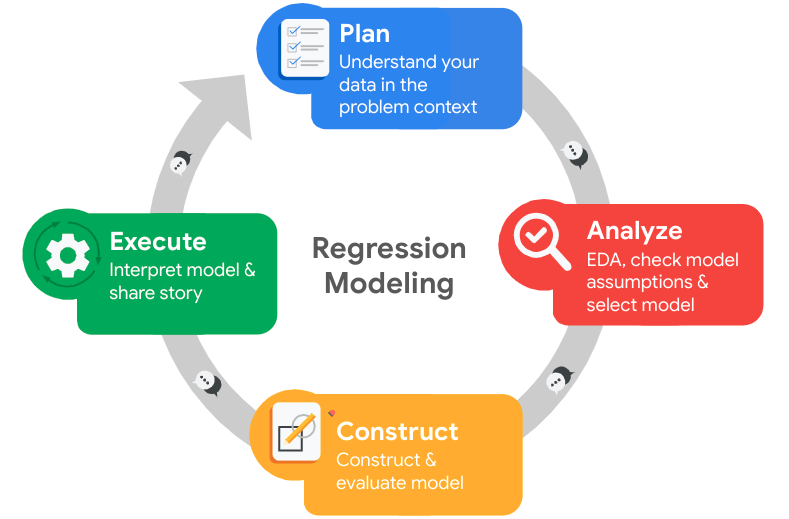

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
The primary stakeholders are the HR department and senior leadership team at Salifort Motors, who need actionable insights to reduce costly employee turnover. Secondary stakeholders include department managers who will act on recommendations.

- What are you trying to solve or accomplish?
I am trying to build a model that predicts whether an employee will leave the company, and to identify the key factors driving attrition. If successful, HR can proactively intervene to improve retention before employees decide to leave.

- What are your initial observations when you explore the data?
The dataset has 14,999 rows and 10 columns with no missing values, but contains 3,008 duplicate rows (about 20% of the data). The target variable 'left' is imbalanced — approximately 83% of employees stayed and 17% left. Satisfaction level appears to have the strongest negative correlation with leaving.

- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- pandas documentation: https://pandas.pydata.org/docs/
- scikit-learn documentation: https://scikit-learn.org/stable/
- seaborn documentation: https://seaborn.pydata.org/
- Coursera GADC course materials

- Do you have any ethical considerations in this stage?
Yes. Employee survey data is sensitive. The model must be used to improve working conditions for all employees, not to surveil or penalize individuals. No employee should be flagged or identified by name based on model predictions.



[Double-click to enter your responses here.]

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
### YOUR CODE HERE ###

# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
### YOUR CODE HERE ###
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                           'average_montly_hours': 'average_monthly_hours',
                           'time_spend_company': 'tenure',
                           'Department': 'department'})

# Display all column names after the update
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

In [9]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df1 = df0.drop_duplicates(keep='first')

# Display first few rows of new dataframe as needed
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

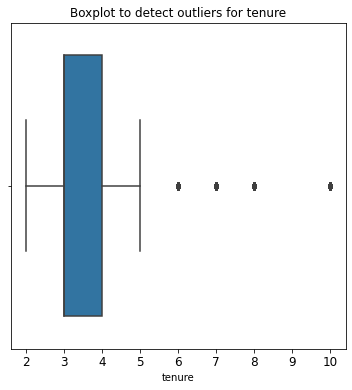

In [11]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df1['tenure'])
plt.show()

In [12]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###

# Compute the 25th percentile value in `tenure`
percentile25 = df1['tenure'].quantile(0.25)

# Compute the 75th percentile value in `tenure`
percentile75 = df1['tenure'].quantile(0.75)

# Compute the interquartile range in `tenure`
iqr = percentile75 - percentile25

# Define the upper limit and lower limit for non-outlier values in `tenure`
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Identify subset of data containing outliers in `tenure`
outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]

# Count how many rows in the data contain outliers in `tenure`
print("Number of rows in the data containing outliers in `tenure`:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data containing outliers in `tenure`: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
Employees who left clustered into two groups: those working 240–315 hours/month with near-zero satisfaction (burned out), and those working slightly below average with satisfaction around 0.4 (possibly feeling undervalued). All employees with 7 projects left the company. Very few employees who were promoted in the last 5 years left. Satisfaction level has the strongest negative correlation with leaving (-0.39).


- What do you observe about the distributions in the data?
The 'left' column is imbalanced — 83.4% stayed, 16.6% left. Satisfaction level is skewed left among employees who left. Monthly hours show two distinct clusters for leavers, suggesting different types of burnout. Four-year employees show an unusually low satisfaction compared to other tenure groups.

- What transformations did you make with your data? Why did you chose to make those decisions?
I removed 3,008 duplicate rows because with several continuous variables across 10 columns, it is very unlikely that two different employees would have identical values for every variable. I renamed four columns to snake_case for consistency. I identified 824 outliers in the tenure column using the IQR method (lower limit: 1.5, upper limit: 5.5).

- What are some purposes of EDA before constructing a predictive model?
EDA helps identify missing data, duplicates, and outliers that could bias models. It reveals class imbalance requiring stratified splitting. It exposes relationships between variables that inform feature selection. It can reveal potential data leakage issues, such as the unusual clustering in satisfaction_level and average_monthly_hours plots.

- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- pandas: https://pandas.pydata.org/docs/
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/

- Do you have any ethical considerations in this stage?
The satisfaction_level variable is sensitive — it reflects how employees feel, and using it directly may mean the model is predicting outcomes based on unhappiness rather than structural causes. This raises concerns about using the model as a surveillance tool rather than a policy improvement tool.




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [13]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
print(df1['left'].value_counts())
print()

# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
print(df1['left'].value_counts(normalize=True))

0    10000
1     1991
Name: left, dtype: int64

0    0.833959
1    0.166041
Name: left, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

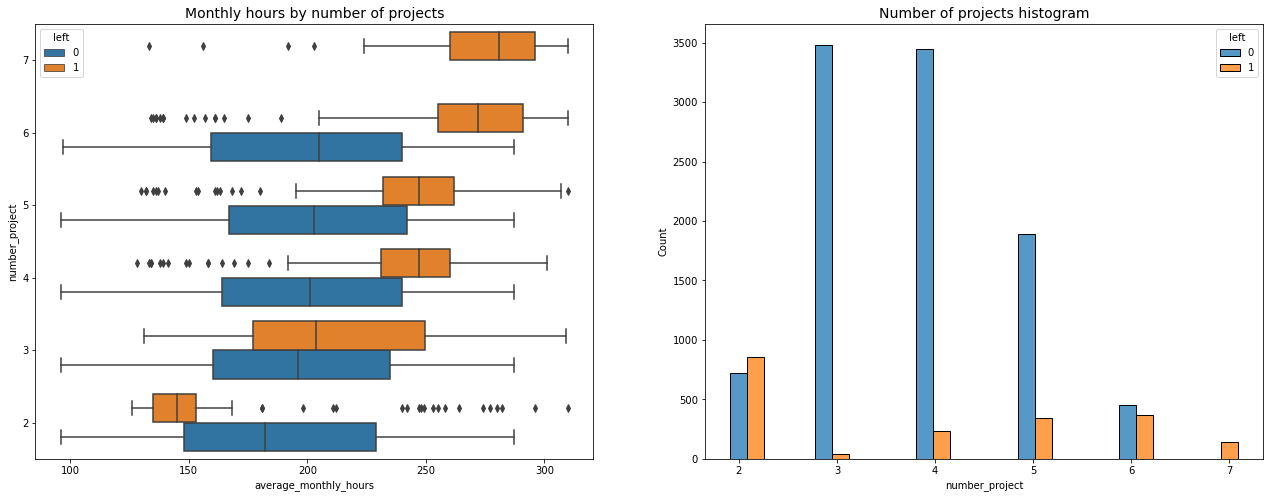

In [14]:
# Create a plot as needed
### YOUR CODE HERE ###

fig, ax = plt.subplots(1, 2, figsize=(22,8))

sns.boxplot(data=df1, x='average_monthly_hours', y='number_project',
            hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left',
             multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

plt.show()

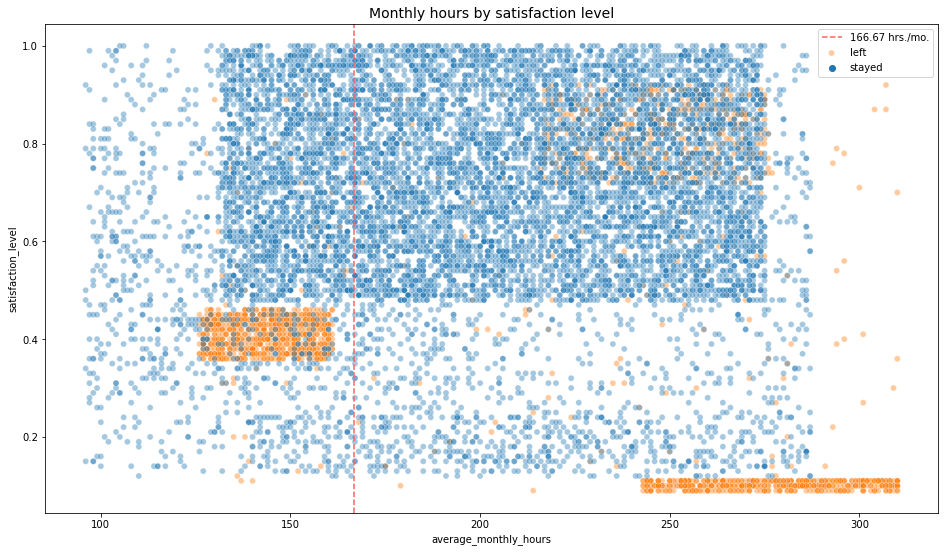

In [15]:
# Create a plot as needed
### YOUR CODE HERE ###

plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level',
                hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by satisfaction level', fontsize='14');

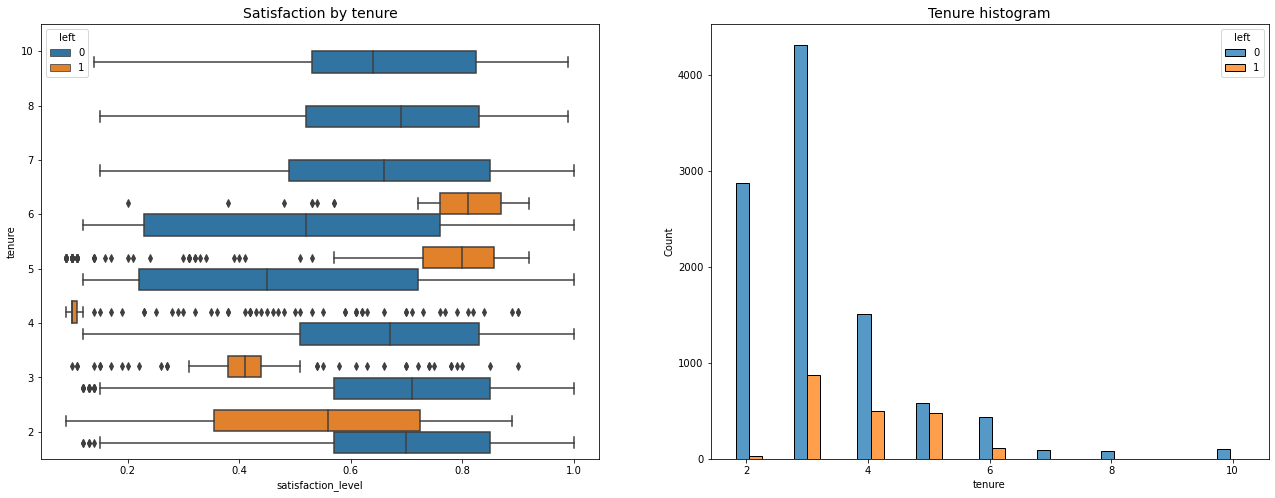

In [16]:
# Create a plot as needed
### YOUR CODE HERE ###

fig, ax = plt.subplots(1, 2, figsize=(22,8))

sns.boxplot(data=df1, x='satisfaction_level', y='tenure',
            hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by tenure', fontsize='14')

sns.histplot(data=df1, x='tenure', hue='left',
             multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure histogram', fontsize='14')

plt.show();

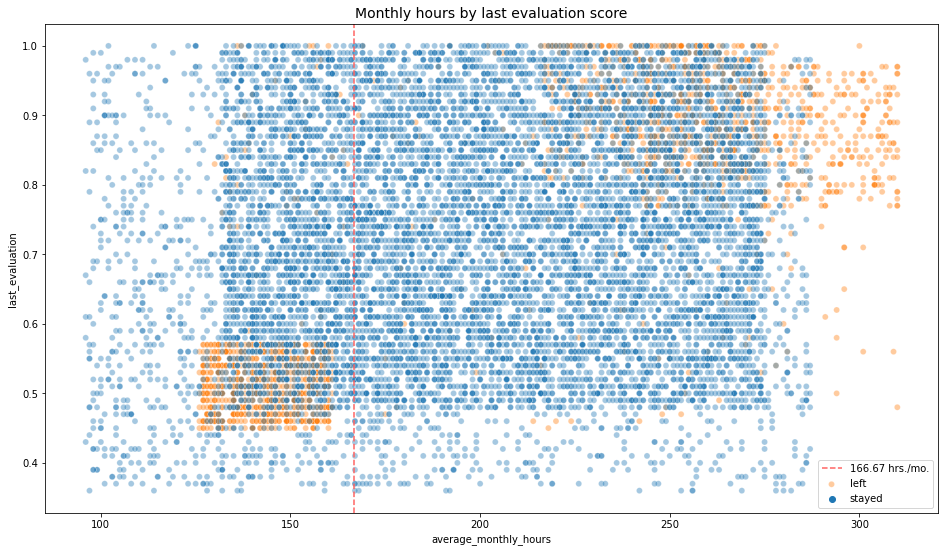

In [17]:
# Create a plot as needed
### YOUR CODE HERE ###

plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation',
                hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

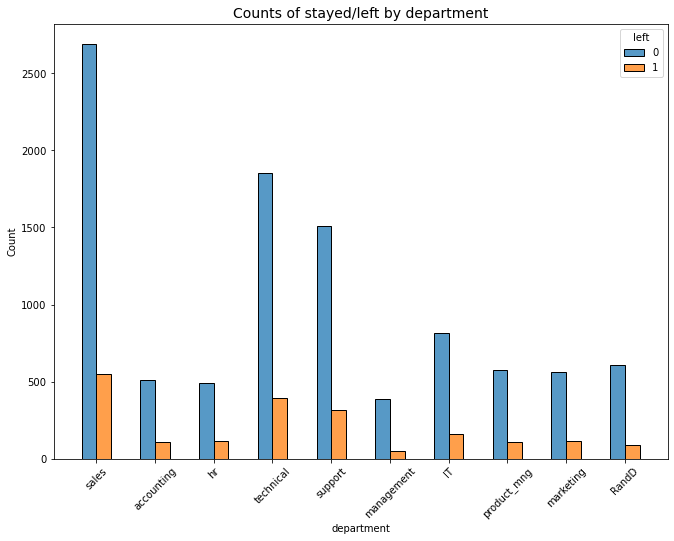

In [18]:
# Create a plot as needed
### YOUR CODE HERE ###

plt.figure(figsize=(11,8))
sns.histplot(data=df1, x='department', hue='left', discrete=1,
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation='45')
plt.title('Counts of stayed/left by department', fontsize=14);

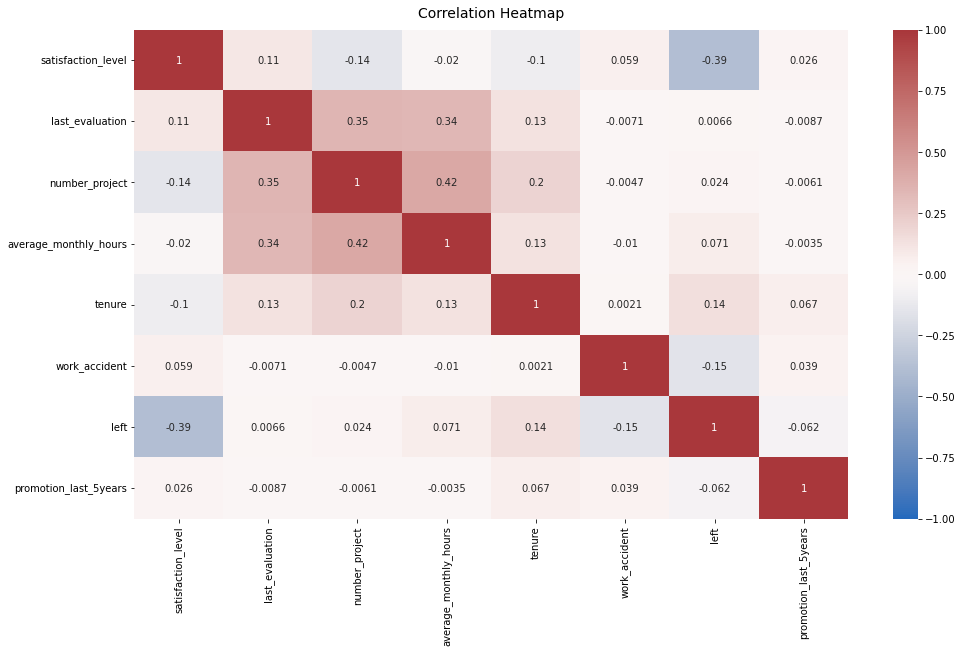

In [19]:
# Create a plot as needed
### YOUR CODE HERE ###

plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df0.corr(), vmin=-1, vmax=1, annot=True,
                      cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

### Insights

[What insights can you gather from the plots you created to visualize the data? Double-click to enter your responses here.]
Employees are leaving primarily due to overwork and lack of recognition. Two distinct groups of leavers emerge: those working 240–315 hours per month with near-zero satisfaction (burned out and likely fired or forced out), and those working slightly below the 166.67 hour average with satisfaction around 0.4 (possibly feeling undervalued relative to peers who work more). All employees assigned 7 projects left the company. Almost no employees promoted in the last 5 years left. Four-year employees show an unusually low satisfaction dip compared to all other tenure groups. Department is not a meaningful predictor — attrition is spread proportionally across all departments, suggesting the problem is company-wide rather than department-specific. The correlation heatmap confirms satisfaction_level has the strongest negative correlation with leaving (-0.39).

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
Yes. The Round 1 model scores are suspiciously high (AUC ~0.98), which suggests possible data leakage. The satisfaction_level and average_monthly_hours variables may already reflect an employee's decision to leave, rather than being independent predictors. The unusual clustering visible in the scatter plots is also consistent with synthetic or manipulated data.

- Which independent variables did you choose for the model and why?
Round 1: All available variables — satisfaction_level, last_evaluation, number_project, average_monthly_hours, tenure, work_accident, promotion_last_5years, salary (ordinal encoded), and department (dummy encoded).
Round 2 (feature engineering): Dropped satisfaction_level (leakage risk) and average_monthly_hours, and replaced them with a new binary 'overworked' feature (>175 hrs/month). This better reflects variables HR could realistically observe before an employee decides to leave.

- Are each of the assumptions met?
For logistic regression: The outcome variable is categorical ✓. Observations are independent ✓. No severe multicollinearity (confirmed by heatmap) ✓. Extreme outliers in tenure were removed ✓. The sample size is large ✓.
For tree-based models: No strict assumptions — decision trees and random forests are non-parametric and robust to outliers.

- How well does your model fit the data?
Logistic Regression: precision 80%, recall 83%, F1 80%, accuracy 82%.
Random Forest Round 2 (champion): AUC 93.8%, precision 87.0%, recall 90.4%, F1 88.7%, accuracy 96.2%.

- Can you improve it? Is there anything you would change about the model?
Yes — removing last_evaluation as well would further reduce leakage risk. Testing XGBoost could improve performance. Using SMOTE to address class imbalance and collecting richer features (manager quality, compensation vs. market) would also help.

- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- scikit-learn: https://scikit-learn.org/stable/
- pandas: https://pandas.pydata.org/docs/

- Do you have any ethical considerations in this stage?
The model should not be used to flag or penalize individual employees. Evaluation scores are the top predictor, which means evaluation practices themselves may be biased and should be audited separately.


[Double-click to enter your responses here.]

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This is a binary classification task. The goal is to predict the outcome variable 'left', which can be either 1 (the employee left the company) or 0 (the employee stayed). Since there are only two possible outcomes, this is a binary classification problem.


### Identify the types of models most appropriate for this task.

Since the outcome variable is categorical (binary), the most appropriate model types are:
1. Logistic Regression — a statistical model well-suited for binary classification that provides interpretable coefficients.
2. Tree-based Machine Learning models — Decision Tree and Random Forest classifiers are appropriate because they handle non-linear relationships, are robust to outliers, and provide feature importance scores that help explain which variables most strongly predict employee departure.

### Modeling

Add as many cells as you need to conduct the modeling process.

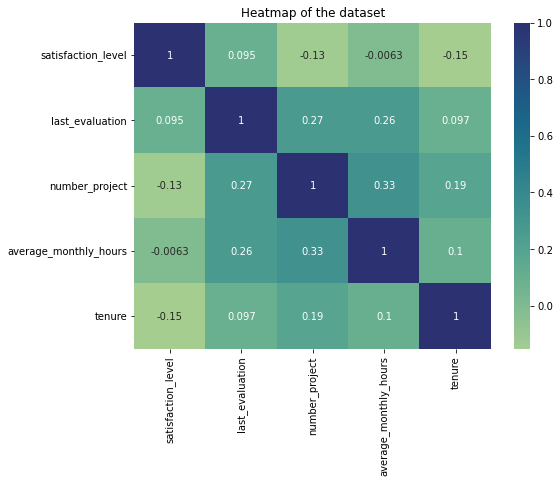

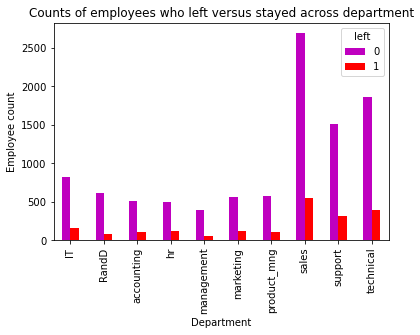

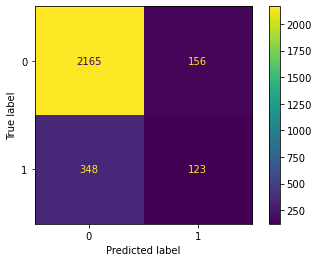

0    0.831468
1    0.168532
Name: left, dtype: float64
                           precision    recall  f1-score   support

Predicted would not leave       0.86      0.93      0.90      2321
    Predicted would leave       0.44      0.26      0.33       471

                 accuracy                           0.82      2792
                macro avg       0.65      0.60      0.61      2792
             weighted avg       0.79      0.82      0.80      2792

Decision Tree Round 1 best params: {'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
Decision Tree Round 1 best AUC: 0.969819392792457
              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.914552  0.916949  0.915707  0.971978  0.969819
Random Forest Round 1 best params: {'max_depth': 5, 'max_features': 1.0, 'max_samples': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 500}
Random Forest Round 1 best AUC: 0.9804250949807172
              model  precision    rec

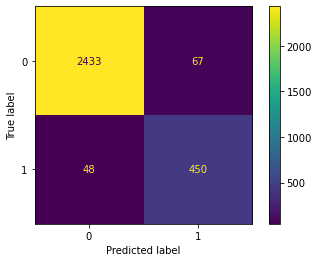

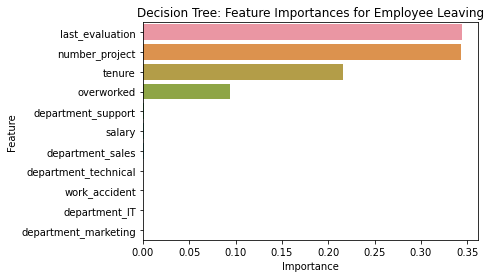

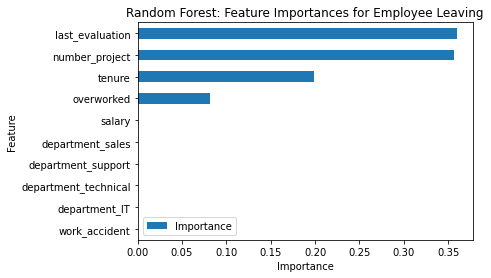

In [20]:
### YOUR CODE HERE ###

# ─── LOGISTIC REGRESSION ──────────────────────────────────────────────────────

# Copy the dataframe and encode variables
df_enc = df1.copy()

df_enc['salary'] = (
    df_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

df_enc = pd.get_dummies(df_enc, drop_first=False)

# Create heatmap of selected features
plt.figure(figsize=(8, 6))
sns.heatmap(df_enc[['satisfaction_level', 'last_evaluation', 'number_project',
                     'average_monthly_hours', 'tenure']]
            .corr(), annot=True, cmap="crest")
plt.title('Heatmap of the dataset')
plt.show()

# Stacked bar plot by department
pd.crosstab(df1['department'], df1['left']).plot(kind='bar', color='mr')
plt.title('Counts of employees who left versus stayed across department')
plt.ylabel('Employee count')
plt.xlabel('Department')
plt.show()

# Remove outliers for logistic regression
df_logreg = df_enc[(df_enc['tenure'] >= lower_limit) & (df_enc['tenure'] <= upper_limit)]

# Isolate outcome variable
y = df_logreg['left']

# Select features
X = df_logreg.drop('left', axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                     stratify=y, random_state=42)

# Fit logistic regression
log_clf = LogisticRegression(random_state=42, max_iter=500).fit(X_train, y_train)

# Predict
y_pred = log_clf.predict(X_test)

# Confusion matrix
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm,
                                  display_labels=log_clf.classes_)
log_disp.plot(values_format='')
plt.show()

# Class balance
print(df_logreg['left'].value_counts(normalize=True))

# Classification report
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))


# ─── TREE-BASED MODELS ────────────────────────────────────────────────────────

# Isolate outcome and features (full df_enc, no outlier removal)
y = df_enc['left']
X = df_enc.drop('left', axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                     stratify=y, random_state=0)

# ── Decision Tree Round 1 ──
tree = DecisionTreeClassifier(random_state=0)

cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]}

scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')
tree1.fit(X_train, y_train)

print("Decision Tree Round 1 best params:", tree1.best_params_)
print("Decision Tree Round 1 best AUC:", tree1.best_score_)

# make_results helper function
def make_results(model_name:str, model_object, metric:str):
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'}

    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]})
    return table

tree1_cv_results = make_results('decision tree cv', tree1, 'auc')
print(tree1_cv_results)

# ── Random Forest Round 1 ──
rf = RandomForestClassifier(random_state=0)

cv_params = {'max_depth': [3,5, None],
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500]}

rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')
rf1.fit(X_train, y_train)

print("Random Forest Round 1 best params:", rf1.best_params_)
print("Random Forest Round 1 best AUC:", rf1.best_score_)

rf1_cv_results = make_results('random forest cv', rf1, 'auc')
print(tree1_cv_results)
print(rf1_cv_results)

# get_scores helper function
def get_scores(model_name:str, model, X_test_data, y_test_data):
    preds = model.best_estimator_.predict(X_test_data)
    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]})
    return table

rf1_test_scores = get_scores('random forest1 test', rf1, X_test, y_test)
print(rf1_test_scores)


# ─── FEATURE ENGINEERING — ROUND 2 ───────────────────────────────────────────

# Drop satisfaction_level
df2 = df_enc.drop('satisfaction_level', axis=1)

# Create overworked binary feature
df2['overworked'] = (df2['average_monthly_hours'] > 175).astype(int)

# Drop average_monthly_hours
df2 = df2.drop('average_monthly_hours', axis=1)

# Isolate outcome and features
y = df2['left']
X = df2.drop('left', axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                     stratify=y, random_state=0)

# ── Decision Tree Round 2 ──
tree = DecisionTreeClassifier(random_state=0)

cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]}

tree2 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')
tree2.fit(X_train, y_train)

print("Decision Tree Round 2 best params:", tree2.best_params_)
print("Decision Tree Round 2 best AUC:", tree2.best_score_)

tree2_cv_results = make_results('decision tree2 cv', tree2, 'auc')
print(tree1_cv_results)
print(tree2_cv_results)

# ── Random Forest Round 2 ──
rf = RandomForestClassifier(random_state=0)

cv_params = {'max_depth': [3,5, None],
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500]}

rf2 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')
rf2.fit(X_train, y_train)

print("Random Forest Round 2 best params:", rf2.best_params_)
print("Random Forest Round 2 best AUC:", rf2.best_score_)

rf2_cv_results = make_results('random forest2 cv', rf2, 'auc')
print(tree2_cv_results)
print(rf2_cv_results)

rf2_test_scores = get_scores('random forest2 test', rf2, X_test, y_test)
print(rf2_test_scores)

# Confusion matrix for champion model
preds = rf2.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=rf2.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf2.classes_)
disp.plot(values_format='');
plt.show()

# ── Feature Importances ──

# Decision tree feature importances
tree2_importances = pd.DataFrame(tree2.best_estimator_.feature_importances_,
                                 columns=['gini_importance'],
                                 index=X.columns)
tree2_importances = tree2_importances.sort_values(by='gini_importance', ascending=False)
tree2_importances = tree2_importances[tree2_importances['gini_importance'] != 0]

sns.barplot(data=tree2_importances, x="gini_importance",
            y=tree2_importances.index, orient='h')
plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()

# Random forest feature importances
feat_impt = rf2.best_estimator_.feature_importances_
ind = np.argpartition(rf2.best_estimator_.feature_importances_, -10)[-10:]
feat = X.columns[ind]
feat_impt = feat_impt[ind]

y_df = pd.DataFrame({"Feature":feat, "Importance":feat_impt})
y_sort_df = y_df.sort_values("Importance")
fig = plt.figure()
ax1 = fig.add_subplot(111)
y_sort_df.plot(kind='barh', ax=ax1, x="Feature", y="Importance")
ax1.set_title("Random Forest: Feature Importances for Employee Leaving", fontsize=12)
ax1.set_ylabel("Feature")
ax1.set_xlabel("Importance")
plt.show()

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
The four most important features predicting employee departure are: last_evaluation score, number_project, tenure, and overworked status (working >175 hours/month). Employees leave because they are overworked and under-rewarded. All employees assigned 7 projects left. Almost no promoted employees left.

- What business recommendations do you propose based on the models built?
1. Cap the number of projects at 5 per employee to prevent burnout.
2. Investigate why 4-year employees have unusually low satisfaction — consider structured check-ins at the 3-year mark.
3. Either reward employees for working longer hours or don't require them to do so.
4. Make overtime policies transparent — if long hours are expected, communicate this clearly.
5. Increase promotion frequency and transparency — almost no promoted employee left.

- What potential recommendations would you make to your manager/company?
Focus on structural policy changes rather than individual-level interventions. Hold company-wide discussions about workload fairness. Audit evaluation practices — high evaluation scores should not require working 200+ hours per month.

- Do you think your model could be improved? Why or why not? How?
Yes. Removing last_evaluation from features would further reduce potential data leakage. Testing XGBoost could improve AUC. Collecting richer features such as manager quality ratings, compensation vs. industry benchmarks, and team size would improve real-world predictive power.

- Given what you know about the data and the models you were using, what other questions could you address for the team?
Can we predict which employees are at risk of receiving low evaluation scores? Is there bias in how evaluations are assigned across departments? Can K-means clustering identify distinct employee segments with different retention strategies?

- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- scikit-learn: https://scikit-learn.org/stable/
- seaborn: https://seaborn.pydata.org/
- pandas: https://pandas.pydata.org/docs/

- Do you have any ethical considerations in this stage?
No individual employee should be shown their predicted risk score. All findings should be used to improve company-wide policies. The model should be regularly audited for fairness across departments and salary levels.


Double-click to enter your responses here.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

**Logistic Regression:**
The logistic regression model achieved precision of 80%, recall of 83%, F1-score of 80% (all weighted averages), and accuracy of 82% on the test set. It performs moderately well but struggles to identify employees who will leave (recall of 26% for the positive class).

**Tree-based Machine Learning:**
After conducting feature engineering (dropping satisfaction_level, creating an 'overworked' binary feature), the decision tree model achieved AUC of 93.8%, precision of 87.0%, recall of 90.4%, F1-score of 88.7%, and accuracy of 96.2% on the test set. The random forest model performed similarly on AUC and modestly outperformed the decision tree overall. The random forest is selected as the champion model.

### Conclusion, Recommendations, Next Steps

**Conclusion:**
The models and feature importances confirm that employees at Salifort Motors are leaving primarily due to overwork and lack of recognition. The random forest model (AUC 93.8%, accuracy 96.2%) can reliably identify employees at risk of leaving based on their workload, evaluation scores, and tenure.

**Recommendations:**
1. Cap the number of projects per employee at 5 to reduce burnout.
2. Investigate the satisfaction drop at 4 years of tenure — consider structured career development conversations at the 3-year mark.
3. Either fairly compensate employees for working overtime or reduce the expectation of long hours.
4. Clarify and communicate overtime policies company-wide.
5. Reform promotion practices — increase frequency and transparency. Almost no promoted employee left the company.
6. High evaluation scores should not be reserved only for employees who work 200+ hours per month — implement a proportionate recognition scale.

**Next Steps:**
- Remove last_evaluation from the model features to fully eliminate data leakage risk and assess how predictions change.
- Test XGBoost for potential performance improvements.
- Explore K-means clustering on this dataset to identify distinct employee segments.
- Validate findings with qualitative exit interview data before implementing major policy changes.
- Retrain the model periodically as workforce conditions evolve.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.